# Teacher-Student Ratio and NAT Perfomance — Correlation Analysis
A correlation analysis of NAT performance of Grade 6 students across 5 regions (CAR, Region I, Region III, Region VIII, Region IX) to number of students per teacher. Initial hypothesis is that having more than 40 students per teacher would divide the teachers' attention and would lead to a reduction in quality.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sqlalchemy import create_engine

## Load the dataset

In [81]:
deped_master = pd.read_excel(r"..\data\outputs\master_school_data_2023_24.xlsx")

In [82]:
deped_master.head()

,school_id,school_name,region,division,kinder_male,kinder_female,g1_male,g1_female,g2_male,g2_female,...,es_teacher_iii,es_teacher_ii,es_teacher_i,n_test_takers,filipino_mps,english_mps,math_mps,science_mps,araling_panlipunan_mps,overall_mps
0,100001,Apaleng-Libtong ES,Region I,Ilocos Norte,4,5,3,2,5,7,...,4.0,NaN,NaN,6,66.666667,54.938272,61.538462,37.654321,33.333333,50.746269
1,100002,Bacarra CES,Region I,Ilocos Norte,26,25,33,25,18,29,...,13.0,2.0,NaN,10,55.925926,55.555556,35.000000,36.296296,47.037037,46.044776
2,100003,Buyon ES,Region I,Ilocos Norte,8,10,11,10,11,4,...,6.0,NaN,1.0,4,81.481481,93.518519,79.807692,74.074074,81.481481,82.089552
3,100004,Ganagan Elementary School,Region I,Ilocos Norte,9,8,5,4,6,5,...,4.0,2.0,NaN,2,83.333333,79.629630,78.846154,66.666667,68.518519,75.373134
4,100005,Macupit ES,Region I,Ilocos Norte,5,3,5,2,3,2,...,3.0,NaN,NaN,6,79.012346,66.666667,78.205128,48.148148,82.098765,70.771144


## Data Description

Initial inspection reveals 6,636 school records across 5 regions. 
Key columns for this analysis include teacher position counts 
(es_teacher_i through es_master_teacher_iv), grade-level 
enrollment by gender, and NAT subject scores for Grade 6.

Notable data quality issues identified:
- Teacher position columns contain significant null values
- Teacher-student ratio produces inf values for schools with 
  zero recorded teachers
- NAT scores reflect Grade 6 performance only for SY 2023-24

In [83]:
deped_master.describe()

,school_id,kinder_male,kinder_female,g1_male,g1_female,g2_male,g2_female,g3_male,g3_female,g4_male,...,es_teacher_iii,es_teacher_ii,es_teacher_i,n_test_takers,filipino_mps,english_mps,math_mps,science_mps,araling_panlipunan_mps,overall_mps
count,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,...,5465.000000,3036.000000,4658.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000
mean,171684.380199,18.322483,16.910488,19.732068,18.012206,20.049729,18.574292,20.498192,19.079415,18.980711,...,6.543824,2.205863,3.636325,7.950723,66.052370,63.672121,56.397593,54.014724,62.940507,60.646940
std,118952.059550,24.468635,22.670374,26.870219,24.751644,27.287610,25.614540,26.242206,25.012368,25.677296,...,6.220741,2.030276,4.475926,8.948053,12.932123,16.828350,19.475852,15.773303,17.121023,14.621344
min,100000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,14.814815,12.962963,7.692308,9.259259,9.259259,11.940299
25%,106051.750000,6.000000,5.000000,6.000000,5.000000,6.000000,5.750000,7.000000,6.000000,6.000000,...,3.000000,1.000000,1.000000,3.000000,57.407407,51.851852,40.384615,41.666667,49.626136,49.626866
50%,123212.500000,11.000000,10.000000,11.000000,10.000000,12.000000,11.000000,12.000000,11.000000,11.000000,...,5.000000,2.000000,2.000000,6.000000,66.666667,65.432099,55.769231,54.074074,64.814815,61.567164
75%,135630.250000,21.000000,20.000000,23.000000,21.000000,23.000000,21.000000,24.000000,22.000000,22.000000,...,8.000000,3.000000,4.000000,10.000000,75.661376,76.543210,72.435897,66.666667,76.829450,72.395833
max,502375.000000,408.000000,369.000000,430.000000,439.000000,437.000000,413.000000,374.000000,388.000000,387.000000,...,75.000000,28.000000,74.000000,117.000000,98.456790,100.000000,100.000000,92.592593,100.000000,92.910448


In [84]:
deped_master.columns

Index(['school_id', 'school_name', 'region', 'division', 'kinder_male',
       'kinder_female', 'g1_male', 'g1_female', 'g2_male', 'g2_female',
       'g3_male', 'g3_female', 'g4_male', 'g4_female', 'g5_male', 'g5_female',
       'g6_male', 'g6_female', 'g7_male', 'g7_female', 'g8_male', 'g8_female',
       'g9_male', 'g9_female', 'g10_male', 'g10_female',
       'es_master_teacher_iv', 'es_master_teacher_iii', 'es_master_teacher_ii',
       'es_master_teacher_i', 'es_teacher_iii', 'es_teacher_ii',
       'es_teacher_i', 'n_test_takers', 'filipino_mps', 'english_mps',
       'math_mps', 'science_mps', 'araling_panlipunan_mps', 'overall_mps'],
      dtype='str')

In [85]:
deped_master.dtypes

school_id                   int64
school_name                   str
region                        str
division                      str
kinder_male                 int64
kinder_female               int64
g1_male                     int64
g1_female                   int64
g2_male                     int64
g2_female                   int64
g3_male                     int64
g3_female                   int64
g4_male                     int64
g4_female                   int64
g5_male                     int64
g5_female                   int64
g6_male                     int64
g6_female                   int64
g7_male                     int64
g7_female                   int64
g8_male                     int64
g8_female                   int64
g9_male                     int64
g9_female                   int64
g10_male                    int64
g10_female                  int64
es_master_teacher_iv      float64
es_master_teacher_iii     float64
es_master_teacher_ii      float64
es_master_teac

## Data Cleaning
Missing value imputations. Replacing nulls with 0 for better and accurate data aggregation

In [86]:
# Treat nulls as 0
teacher_cols = ['es_master_teacher_iv', 'es_master_teacher_iii',
                'es_master_teacher_ii', 'es_master_teacher_i',
                'es_teacher_iii', 'es_teacher_ii', 'es_teacher_i']

deped_master[teacher_cols] = deped_master[teacher_cols].fillna(0)

deped_master['total_teachers'] = deped_master[teacher_cols].sum(axis=1)
deped_master['total_master_teachers'] = deped_master[['es_master_teacher_iv',
                                                      'es_master_teacher_iii',
                                                      'es_master_teacher_ii',
                                   'es_master_teacher_i']].sum(axis=1)

deped_master['has_master_teacher'] = deped_master['total_master_teachers'] > 0

## Added columns — Enrollment and Teacher Summaries

Total elementary enrollment (Kinder to Grade 6), JHS enrollment 
(Grade 7 to 10), and total teacher count are calculated by 
summing across individual grade and position columns. These 
aggregated values are used to compute the teacher-student ratio 
per school.

In [87]:
# Engineer summary columns
deped_master['total_es_enrollment'] = (
    deped_master['kinder_male'] + deped_master['kinder_female'] +
    deped_master['g1_male'] + deped_master['g1_female'] +
    deped_master['g2_male'] + deped_master['g2_female'] +
    deped_master['g3_male'] + deped_master['g3_female'] +
    deped_master['g4_male'] + deped_master['g4_female'] +
    deped_master['g5_male'] + deped_master['g5_female'] +
    deped_master['g6_male'] + deped_master['g6_female']
)

deped_master['total_jhs_enrollment'] = (
    deped_master['g7_male'] + deped_master['g7_female'] +
    deped_master['g8_male'] + deped_master['g8_female'] +
    deped_master['g9_male'] + deped_master['g9_female'] +
    deped_master['g10_male'] + deped_master['g10_female']
)

deped_master['total_teachers'] = (
    deped_master['es_teacher_i'] + deped_master['es_teacher_ii'] + 
    deped_master['es_teacher_iii'] + deped_master['es_master_teacher_i'] + 
    deped_master['es_master_teacher_ii'] + deped_master['es_master_teacher_iii'] + 
    deped_master['es_master_teacher_iv']
)

# Calculate teacher-student ratio
deped_master['teacher_student_ratio'] = (
    deped_master['total_es_enrollment'] + deped_master['total_jhs_enrollment']
) / deped_master['total_teachers']

# Replace inf values with NaN
deped_master.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill null values in deped_master with 0
deped_master.fillna(0)

,school_id,school_name,region,division,kinder_male,kinder_female,g1_male,g1_female,g2_male,g2_female,...,math_mps,science_mps,araling_panlipunan_mps,overall_mps,total_teachers,total_master_teachers,has_master_teacher,total_es_enrollment,total_jhs_enrollment,teacher_student_ratio
0,100001,Apaleng-Libtong ES,Region I,Ilocos Norte,4,5,3,2,5,7,...,61.538462,37.654321,33.333333,50.746269,4.0,0.0,False,58,0,14.500000
1,100002,Bacarra CES,Region I,Ilocos Norte,26,25,33,25,18,29,...,35.000000,36.296296,47.037037,46.044776,19.0,4.0,True,402,0,21.157895
2,100003,Buyon ES,Region I,Ilocos Norte,8,10,11,10,11,4,...,79.807692,74.074074,81.481481,82.089552,8.0,1.0,True,128,0,16.000000
3,100004,Ganagan Elementary School,Region I,Ilocos Norte,9,8,5,4,6,5,...,78.846154,66.666667,68.518519,75.373134,7.0,1.0,True,91,0,13.000000
4,100005,Macupit ES,Region I,Ilocos Norte,5,3,5,2,3,2,...,78.205128,48.148148,82.098765,70.771144,3.0,0.0,False,53,0,17.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6631,136401,Doña Nicasia Puyat ES,CAR,Baguio City,21,35,28,24,27,24,...,50.549451,44.444444,63.492063,61.833689,17.0,1.0,True,410,0,24.117647
6632,136403,Apolinario Mabini ES,CAR,Baguio City,104,95,107,122,87,137,...,58.355438,55.044700,59.642401,62.532167,64.0,5.0,True,1771,0,27.671875
6633,221504,Brookspoint Elementary School,CAR,Baguio City,10,14,16,12,17,12,...,46.153846,48.148148,61.728395,58.955224,9.0,1.0,True,195,0,21.666667
6634,221507,Holy Ghost Extension ES,CAR,Baguio City,20,12,22,17,15,24,...,45.192308,61.111111,67.592593,64.925373,10.0,1.0,True,260,0,26.000000


## Schools with Zero Teacher Records

Before calculating teacher-student ratios, schools with no 
recorded teacher positions are identified. Division by zero 
for these schools produces meaningless results and must be 
excluded from ratio analysis.

In [88]:
print((deped_master['total_teachers'] == 0).sum())

814


## Data Filtration
Schools with no recorded teacher positions (n = 814) were excluded 
from teacher-student ratio analysis as division by zero produces 
meaningless results. These exclusions are noted as a data 
quality limitation of the source dataset.

In [89]:
teacher_student_ratio = deped_master[['school_id', 'school_name',
                                       'total_es_enrollment', 
                                       'total_jhs_enrollment', 
                                       'total_teachers', 
                                       'teacher_student_ratio',
                                       'n_test_takers',
                                       'filipino_mps',
                                       'english_mps',
                                       'math_mps',
                                       'science_mps',
                                       'araling_panlipunan_mps',
                                       'overall_mps']].sort_values(by='teacher_student_ratio', ascending=True)

teacher_student_ratio = teacher_student_ratio[teacher_student_ratio['total_teachers'] > 0]

## School-Level Teacher-Student Ratio — Full Overview

In [ ]:
teacher_student_ratio.sort_values(by='teacher_student_ratio', ascending=False).style.format({
        'total_es_enrollment': '{:,.0f}',
        'total_jhs_enrollment': '{:,.0f}',
        'total_teachers': '{:,.0f}',
        'teacher_student_ratio': '{:.4f}'  # Shows 4 decimal places
    })

## Calculating for the Correlation of the Teacher-Student ratio to the Overall NAT score
Finding if the Teacher-Student ratio affect the NAT results of individual schools.

In [91]:
correlation = teacher_student_ratio['teacher_student_ratio'].corr(teacher_student_ratio['overall_mps'])
print(f"Correlation between teacher-student ratio and overall MPS: {correlation:.3f}")

Correlation between teacher-student ratio and overall MPS: -0.024


## Chart — Scatterplot with an added Trendline

Visual representation of the correlation of the 'teacher_student_ratio' to the 'overall_mps'

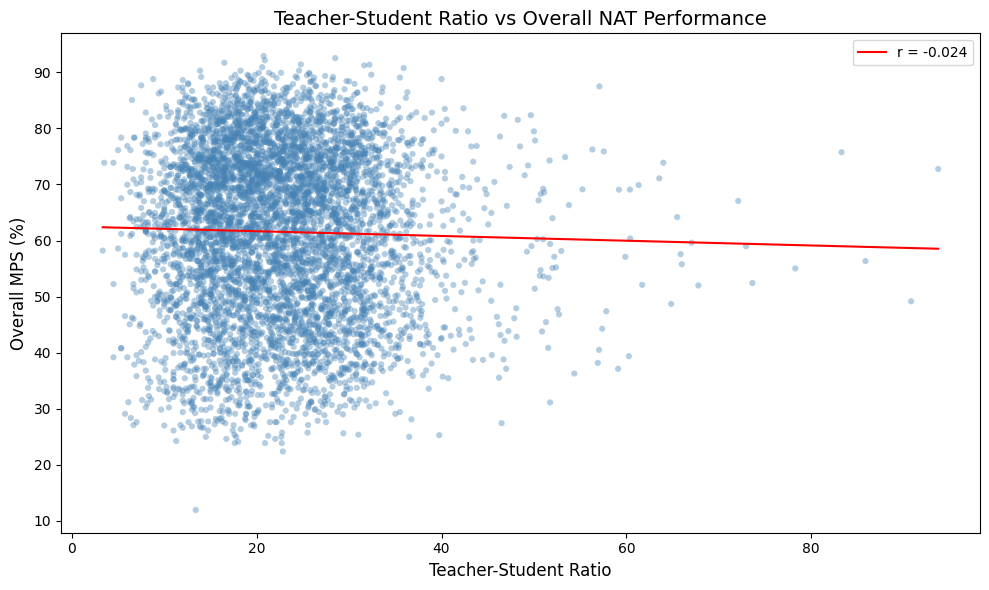

In [92]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(teacher_student_ratio['teacher_student_ratio'], 
           teacher_student_ratio['overall_mps'],
           alpha=0.4,
           color='steelblue',
           edgecolors='none',
           s=20)

# Trend line
z = np.polyfit(teacher_student_ratio['teacher_student_ratio'], 
               teacher_student_ratio['overall_mps'], 1)
p = np.poly1d(z)
x_line = np.linspace(teacher_student_ratio['teacher_student_ratio'].min(), 
                     teacher_student_ratio['teacher_student_ratio'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=1.5, label=f'r = -0.024')

ax.set_xlabel('Teacher-Student Ratio', fontsize=12)
ax.set_ylabel('Overall MPS (%)', fontsize=12)
ax.set_title('Teacher-Student Ratio vs Overall NAT Performance', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## Correlation Analysis — Teacher-Student Ratio vs NAT Performance

### Findings
The Pearson correlation between teacher-student ratio and overall 
NAT MPS is **r = -0.024**, indicating virtually no linear 
relationship between the two variables.

### Interpretation
Teacher-student ratio alone does not appear to be a significant 
predictor of Grade 6 NAT performance across the 5 regions in 
this dataset. The near-zero correlation suggests that simply 
having fewer students per teacher does not guarantee better 
academic outcomes.

### Important Caveats
- Teacher position data contains significant null values treated 
  as zero — this likely undercounts actual teachers per school 
  and may suppress the true correlation
- Analysis is limited to 5 regions and may not reflect 
  nationwide patterns
- Correlation measures linear relationships only — a threshold 
  or non-linear effect cannot be ruled out

### Next Steps
The weak ratio correlation shifts focus to a more specific 
question — does the **presence of Master Teachers** tell a 
different story about academic performance?

## File conversion
The dataset (deped_master) here would be used in Power BI.

In [95]:
server = r'LAPTOP-OCKRNGU5\SQLEXPRESS'
database = 'DepEDdb'

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

engine = create_engine(connection_string)

deped_master.to_sql('master_school_data_2023_24', engine, if_exists='replace', index=False)

21